In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from src.dataset import HandDetectionDataset
import pandas as pd

In [2]:
# test dataset
test_dataset = HandDetectionDataset(root_dir="data/processed_frames/hand_train")
print(f"Test dataset size: {len(test_dataset)}")

Test dataset size: 1551


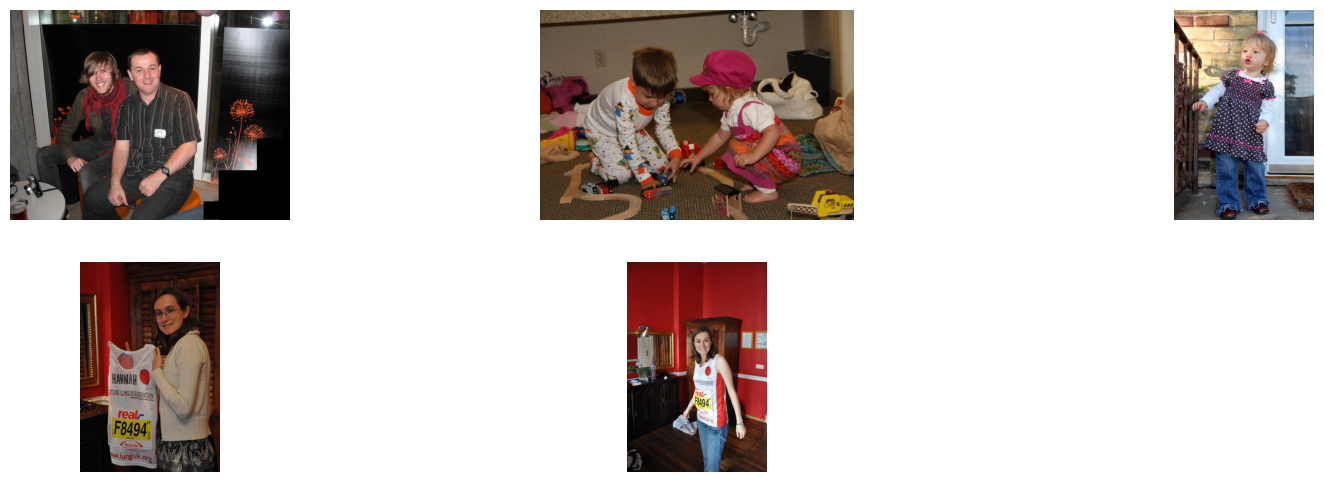

In [3]:
# hiển thị vài bức ảnh từ tập dữ liệu
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 6))
# Hiển thị một số ảnh từ tập dữ liệu kiểm tra
for i in range(5):
    img, label = test_dataset[i]
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

1024 768
Image 0 label: [(0, 0.2353515625, 0.7317708333333334, 0.0712890625, 0.09375), (0, 0.3818359375, 0.87890625, 0.0712890625, 0.11979166666666667), (0, 0.4970703125, 0.8346354166666666, 0.09765625, 0.12630208333333334), (0, 0.4970703125, 0.8346354166666666, 0.09765625, 0.12630208333333334)]
số box 0 label: 4
Bounding box coordinates: x=0.2353515625, y=0.7317708333333334, width=0.0712890625, height=0.09375
Bounding box coordinates: x=0.3818359375, y=0.87890625, width=0.0712890625, height=0.11979166666666667
Bounding box coordinates: x=0.4970703125, y=0.8346354166666666, width=0.09765625, height=0.12630208333333334
Bounding box coordinates: x=0.4970703125, y=0.8346354166666666, width=0.09765625, height=0.12630208333333334


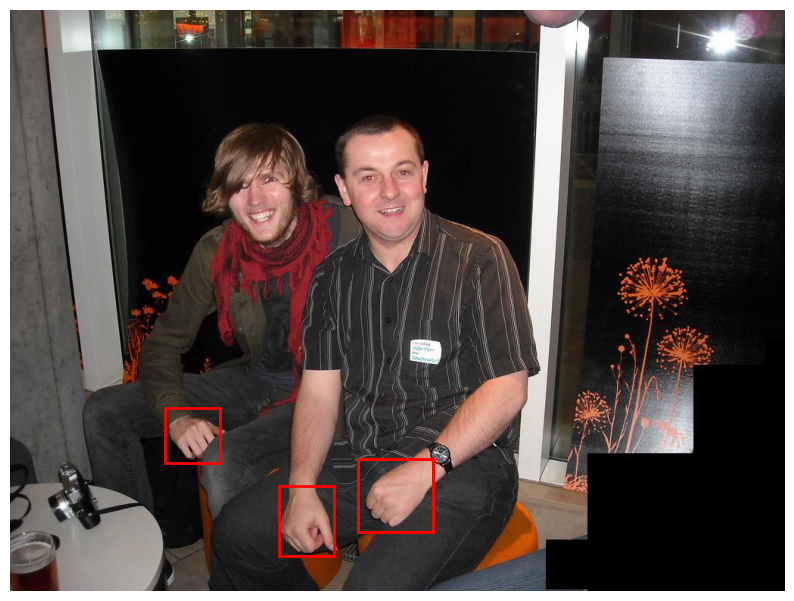

In [4]:
# hien thị nhãn của các ảnh trong tập dữ liệu và vẽ bounding box trong các ảnh
# đây là txt của YOLO format: <class_id> <x_center> <y_center> <width> <height> đã chuẩn hóa về [0, 1]
for i in range(1):
    img, label = test_dataset[i]
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 1, i + 1)
    plt.imshow(img)
    width, height = img.size
    print(width, height)
    print(f"Image {i} label: {label}")
    # Vẽ bounding box
    print(f"số box {i} label: {len(label)}")
    while len(label) > 0:
        id, x, y, w, h = label.pop(0)
        print(f"Bounding box coordinates: x={x}, y={y}, width={w}, height={h}")
        # vẽ bounding box 
        plt.gca().add_patch(plt.Rectangle((x * width - w * width / 2, y * height - h * height / 2), w * width, h * height, edgecolor='red', facecolor='none', linewidth=2))
    plt.axis("off")
plt.show()

In [5]:
for i in range(5):
    img, label = test_dataset[i]
    print(f"Image {i} label: {label}")
    id, x, y, w, h = label[0]
    print(f"Bounding box coordinates: x={x}, y={y}, width={w}, height={h}")

Image 0 label: [(0, 0.2353515625, 0.7317708333333334, 0.0712890625, 0.09375), (0, 0.3818359375, 0.87890625, 0.0712890625, 0.11979166666666667), (0, 0.4970703125, 0.8346354166666666, 0.09765625, 0.12630208333333334), (0, 0.4970703125, 0.8346354166666666, 0.09765625, 0.12630208333333334)]
Bounding box coordinates: x=0.2353515625, y=0.7317708333333334, width=0.0712890625, height=0.09375
Image 1 label: [(0, 0.423828125, 0.7496339677891655, 0.0732421875, 0.13323572474377746), (0, 0.4765625, 0.7335285505124451, 0.0791015625, 0.10980966325036604), (0, 0.650390625, 0.7144948755490483, 0.0751953125, 0.10248901903367497)]
Bounding box coordinates: x=0.423828125, y=0.7496339677891655, width=0.0732421875, height=0.13323572474377746
Image 2 label: [(0, 0.18448023426061494, 0.458984375, 0.1273792093704246, 0.0849609375), (0, 0.6193265007320644, 0.5517578125, 0.1054172767203514, 0.0771484375)]
Bounding box coordinates: x=0.18448023426061494, y=0.458984375, width=0.1273792093704246, height=0.084960937

In [ ]:
# hiển thị vài bức ảnh từ tập test và vẽ bounding box trong các ảnh
data_test = HandDetectionDataset(root_dir="data/processed_frames/hand_test")
print(f"Test dataset size: {len(data_test)}")

Test dataset size: 510


500 375
Image 0 label: [(0, 0.702, 0.6453333333333333, 0.298, 0.45866666666666667)]
số box 0 label: 1
Bounding box coordinates: x=0.702, y=0.6453333333333333, width=0.298, height=0.45866666666666667
375 500
Image 1 label: [(0, 0.6266666666666667, 0.328, 0.176, 0.176)]
số box 1 label: 1
Bounding box coordinates: x=0.6266666666666667, y=0.328, width=0.176, height=0.176
500 333
Image 2 label: [(0, 0.518, 0.8858858858858859, 0.13, 0.18618618618618618)]
số box 2 label: 1
Bounding box coordinates: x=0.518, y=0.8858858858858859, width=0.13, height=0.18618618618618618
500 375
Image 3 label: [(0, 0.052, 0.6106666666666667, 0.226, 0.344)]
số box 3 label: 1
Bounding box coordinates: x=0.052, y=0.6106666666666667, width=0.226, height=0.344
500 331
Image 4 label: [(0, 0.67, 0.42900302114803623, 0.068, 0.10574018126888217)]
số box 4 label: 1
Bounding box coordinates: x=0.67, y=0.42900302114803623, width=0.068, height=0.10574018126888217


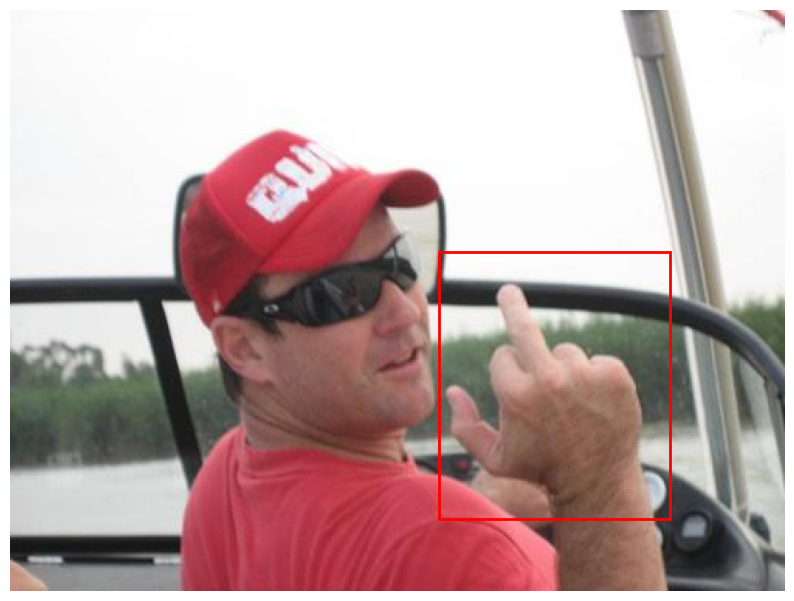

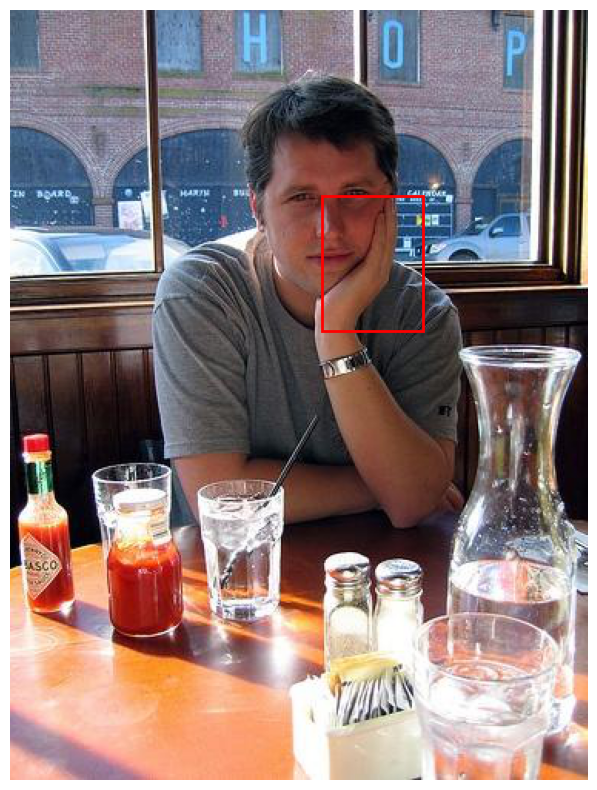

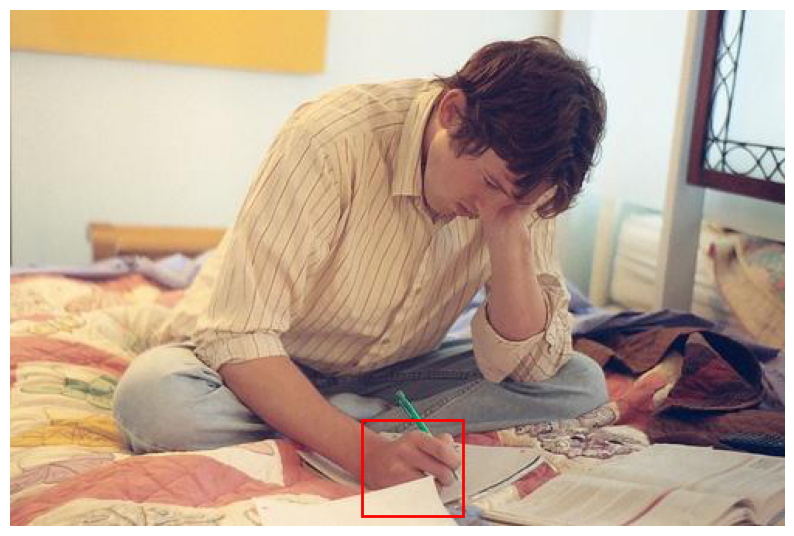

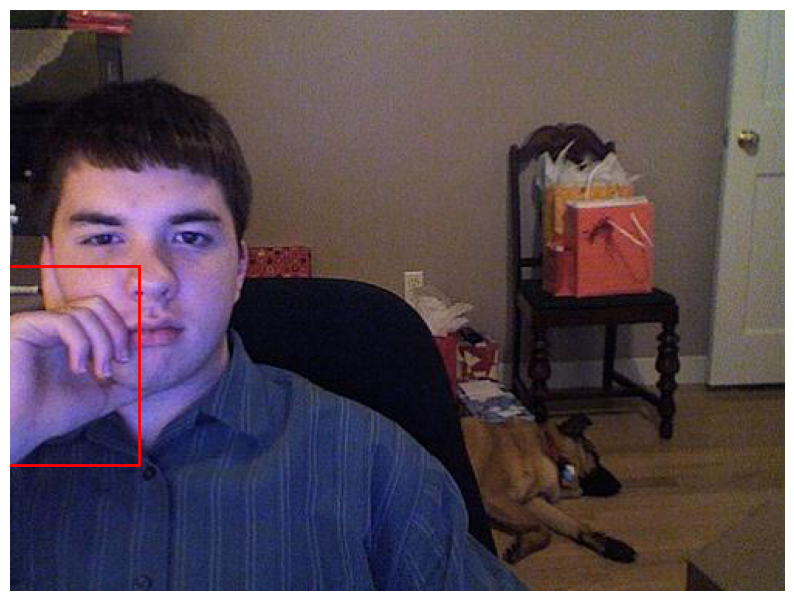

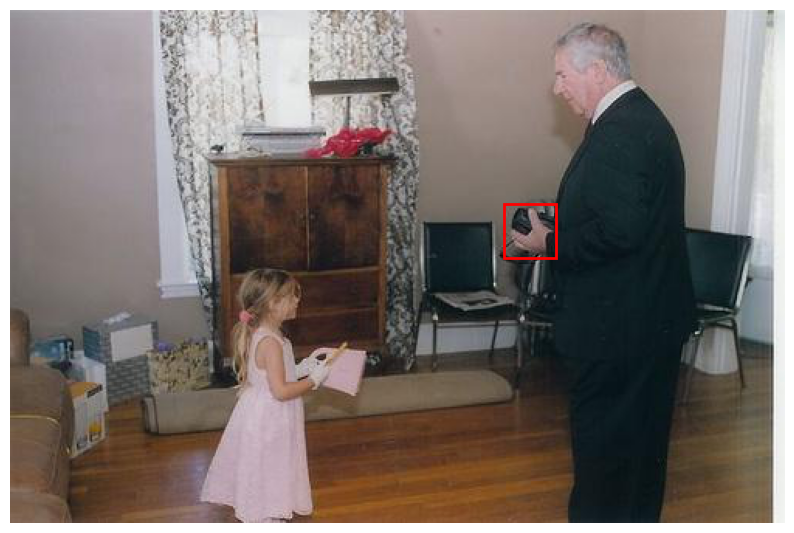

In [7]:
for i in range(5):
    img, label = data_test[i]
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    width, height = img.size
    print(width, height)
    print(f"Image {i} label: {label}")
    # Vẽ bounding box
    print(f"số box {i} label: {len(label)}")
    while len(label) > 0:
        id, x, y, w, h = label.pop(0)
        print(f"Bounding box coordinates: x={x}, y={y}, width={w}, height={h}")
        # vẽ bounding box 
        plt.gca().add_patch(plt.Rectangle((x * width - w * width / 2, y * height - h * height / 2), w * width, h * height, edgecolor='red', facecolor='none', linewidth=2))
    plt.axis("off")